In [35]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from data import prepare_data, make_dataloader
from pathlib import Path
from models import *
import math

In [6]:
DATA_PATH = "../modular_setup_improved/synthetic+real_dataset_filtered.parquet"
EMBEDDING_PATH = "../modular_setup_improved/all_fm-rna_embeddings_filtered.pt"
BIN_EDGES_PATH = "bin_edges.npy"
SEED = 42
N_BINS = 50
DEVICE = "cpu"  # change to "cuda" if available

In [138]:
handpicked_cols = ["gc_content", "mfe", "n_local_minima"]
# handpicked_cols = [
#     "mfe", "n_local_minima", "gc_content",
#     "freq_A", "freq_U", "freq_G", "freq_C",
#     "freq_AA", "freq_AU", "freq_AG", "freq_AC",
#     "freq_UA", "freq_UU", "freq_UG", "freq_UC",
#     "freq_GA", "freq_GU", "freq_GG", "freq_GC",
#     "freq_CA", "freq_CU", "freq_CG", "freq_CC"
# ]

In [139]:
data = prepare_data(DATA_PATH, n_bins=N_BINS, random_state=SEED, handpicked_cols=handpicked_cols, bin_edges_path=BIN_EDGES_PATH)

In [143]:
data.test.sequences[0].shape

(98, 4)

In [144]:
data.test.structures[0].shape

(98, 3)

In [145]:
data.test.static_features[0].shape

(3,)

In [146]:
data.test.row_keys

['10787',
 '1692',
 '2693',
 '8064',
 '321',
 '10389',
 '39',
 '10119',
 '7626',
 '2613',
 '9581',
 '10654',
 '9284',
 '4842',
 '10650',
 '4371',
 '4871',
 '7866',
 '35',
 '8122',
 '335',
 '2795',
 '4637',
 '96',
 '3128',
 '8091',
 '6687',
 '2025',
 '8894',
 '3774',
 '5623',
 '6163',
 '6148',
 '4196',
 '9030',
 '10488',
 '3695',
 '733',
 '9739',
 '7711',
 '3273',
 '5335',
 '10891',
 '9634',
 '5197',
 '3064',
 '7418',
 '3371',
 '3488',
 '311',
 '1350',
 '1155',
 '10038',
 '4033',
 '10255',
 '33',
 '4592',
 '3289',
 '2165',
 '2392',
 '3059',
 '542',
 '3704',
 '4902',
 '483',
 '6119',
 '2754',
 '9478',
 '3398',
 '9391',
 '3914',
 '3318',
 '1002',
 '1488',
 '8663',
 '7778',
 '2088',
 '8089',
 '2018',
 '4125',
 '10032',
 '4634',
 '6901',
 '2936',
 '4445',
 '10882',
 '7383',
 '543',
 '10883',
 '7280',
 '10395',
 '9100',
 '6734',
 '6530',
 '8904',
 '718',
 '1964',
 '5482',
 '10339',
 '6408',
 '6123',
 '10915',
 '1472',
 '4087',
 '7486',
 '9590',
 '7642',
 '5011',
 '3027',
 '3551',
 '119',
 '8

In [147]:
data.bin_edges/np.log(10)

array([-3.        , -2.76010949, -2.52021898, -2.28032848, -2.04043797,
       -1.80054746, -1.56065695, -1.32076644, -1.08087594, -0.84098543,
       -0.60109492, -0.36120441, -0.1213139 ,  0.11857661,  0.35846711,
        0.59835762,  0.83824813,  1.07813864,  1.31802915,  1.55791965,
        1.79781016,  2.03770067,  2.27759118,  2.51748169,  2.75737219,
        2.9972627 ,  3.23715321,  3.47704372,  3.71693423,  3.95682474,
        4.19671524,  4.43660575,  4.67649626,  4.91638677,  5.15627728,
        5.39616778,  5.63605829,  5.8759488 ,  6.11583931,  6.35572982,
        6.59562032,  6.83551083,  7.07540134,  7.31529185,  7.55518236,
        7.79507287,  8.03496337,  8.27485388,  8.51474439,  8.7546349 ,
        8.99452541])

In [148]:
data.test.targets.shape

(1549, 50)

In [149]:
data.test.row_keys

['10787',
 '1692',
 '2693',
 '8064',
 '321',
 '10389',
 '39',
 '10119',
 '7626',
 '2613',
 '9581',
 '10654',
 '9284',
 '4842',
 '10650',
 '4371',
 '4871',
 '7866',
 '35',
 '8122',
 '335',
 '2795',
 '4637',
 '96',
 '3128',
 '8091',
 '6687',
 '2025',
 '8894',
 '3774',
 '5623',
 '6163',
 '6148',
 '4196',
 '9030',
 '10488',
 '3695',
 '733',
 '9739',
 '7711',
 '3273',
 '5335',
 '10891',
 '9634',
 '5197',
 '3064',
 '7418',
 '3371',
 '3488',
 '311',
 '1350',
 '1155',
 '10038',
 '4033',
 '10255',
 '33',
 '4592',
 '3289',
 '2165',
 '2392',
 '3059',
 '542',
 '3704',
 '4902',
 '483',
 '6119',
 '2754',
 '9478',
 '3398',
 '9391',
 '3914',
 '3318',
 '1002',
 '1488',
 '8663',
 '7778',
 '2088',
 '8089',
 '2018',
 '4125',
 '10032',
 '4634',
 '6901',
 '2936',
 '4445',
 '10882',
 '7383',
 '543',
 '10883',
 '7280',
 '10395',
 '9100',
 '6734',
 '6530',
 '8904',
 '718',
 '1964',
 '5482',
 '10339',
 '6408',
 '6123',
 '10915',
 '1472',
 '4087',
 '7486',
 '9590',
 '7642',
 '5011',
 '3027',
 '3551',
 '119',
 '8

In [150]:
BANDWIDTH = 2
weights = torch.load('checkpoints/best_bilstm_v2.pth')
#weights = torch.load('checkpoints/best_glm_baseline_v2.pth')

In [151]:
static_dim = data.train.static_features.shape[1]
output_dim = data.train.targets.shape[1]

In [152]:
model = DynamicHybridLSTM(hidden_size=64, num_layers=1, static_feature_size=static_dim, output_size=output_dim, mlp_hidden_size=64, bidirectional=False)
#model = GLMBaseline(static_feature_size=static_dim, output_size=output_dim)

In [153]:
model.load_state_dict(weights)

<All keys matched successfully>

In [154]:
data.test.sequences[0].shape

(98, 4)

In [155]:
data.test.structures[0].shape

(98, 3)

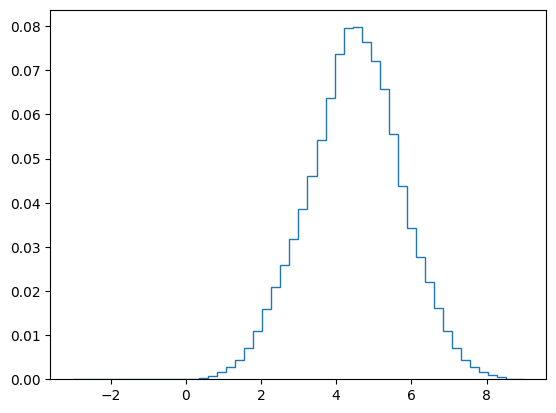

In [156]:
logits = model.forward(torch.from_numpy(data.test.sequences[0]),
                       torch.from_numpy(data.test.structures[0]),
                       torch.from_numpy(data.test.static_features[0]),
                       embeddings=None)

weights = torch.softmax(logits, dim=-1) # shape (batch_size, num_bins)
xgrid = torch.outer(torch.ones(weights.shape[-1]), torch.arange(weights.shape[-1])) # shape (num_bins, num_bins)
means = xgrid.T # shape (num_bins, num_bins)
bandwidth = BANDWIDTH
gaussians = 1/(math.sqrt(2*math.pi)*bandwidth)*torch.exp(-0.5*((xgrid - means)/bandwidth)**2) # shape (num_bins, num_bins)
probs = weights @ gaussians # shape (batch_size, num_bins)
normalizations = torch.ones(probs.shape[-1]) # shape (batch_size, num_bins)
probs /= normalizations # shape (batch_size, num_bins)
probs = probs.detach().numpy()

plt.stairs(probs, data.bin_edges/np.log(10))

In [157]:
probs

array([1.10649694e-06, 1.39556118e-06, 1.59164847e-06, 1.66280915e-06,
       1.59571380e-06, 1.41050657e-06, 1.16186459e-06, 9.28185159e-07,
       8.31448347e-07, 1.19280958e-06, 3.18069192e-06, 1.10741448e-05,
       3.87809050e-05, 1.23402831e-04, 3.39428661e-04, 7.87557336e-04,
       1.54654752e-03, 2.67170020e-03, 4.34702775e-03, 6.99969893e-03,
       1.09488135e-02, 1.58237685e-02, 2.08258834e-02, 2.58622933e-02,
       3.17166075e-02, 3.86791267e-02, 4.61414121e-02, 5.42066582e-02,
       6.37904778e-02, 7.36294314e-02, 7.96569139e-02, 7.97521472e-02,
       7.64143839e-02, 7.21741468e-02, 6.57198876e-02, 5.54967187e-02,
       4.38334048e-02, 3.43682133e-02, 2.76854858e-02, 2.19493192e-02,
       1.61780883e-02, 1.09724049e-02, 7.04076886e-03, 4.40607732e-03,
       2.71165604e-03, 1.60732295e-03, 8.75639031e-04, 4.14904353e-04,
       1.63859338e-04, 5.29152348e-05], dtype=float32)

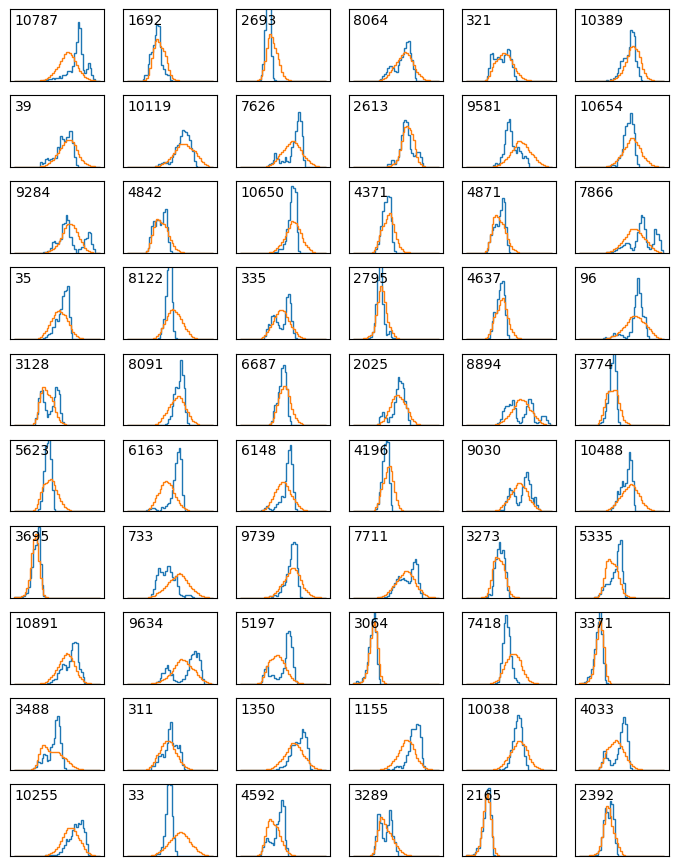

In [158]:
width_inch = 8.5
height_inch = 11
n_x = 6
n_y = 10
fig, axs = plt.subplots(n_y, n_x, figsize=(width_inch, height_inch))

offset = 0
for i in range(offset, len(data.test.row_keys)+offset):
    if i-offset == n_x*n_y:
        break

    i_x = (i-offset) % n_x
    i_y = int((i-offset)/n_x)

    ax = axs[i_y][i_x]
    ax.stairs(data.test.targets[i], data.bin_edges/np.log(10))

    logits = model.forward(torch.from_numpy(data.test.sequences[i]),
                           torch.from_numpy(data.test.structures[i]),
                           torch.from_numpy(data.test.static_features[i]),
                        embeddings=None)

    weights = torch.softmax(logits, dim=-1) # shape (batch_size, num_bins)
    xgrid = torch.outer(torch.ones(weights.shape[-1]), torch.arange(weights.shape[-1])) # shape (num_bins, num_bins)
    means = xgrid.T # shape (num_bins, num_bins)
    bandwidth = BANDWIDTH
    gaussians = 1/(math.sqrt(2*math.pi)*bandwidth)*torch.exp(-0.5*((xgrid - means)/bandwidth)**2) # shape (num_bins, num_bins)
    probs = weights @ gaussians # shape (batch_size, num_bins)
    normalizations = torch.ones(probs.shape[-1]) # shape (batch_size, num_bins)
    probs /= normalizations # shape (batch_size, num_bins)
    probs = probs.detach().numpy()
    ax.stairs(probs, data.bin_edges/np.log(10))

    ax.set_ylim(0,0.2)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.text(0.05, 0.95, str(data.test.row_keys[i]), transform=ax.transAxes, verticalalignment='top')

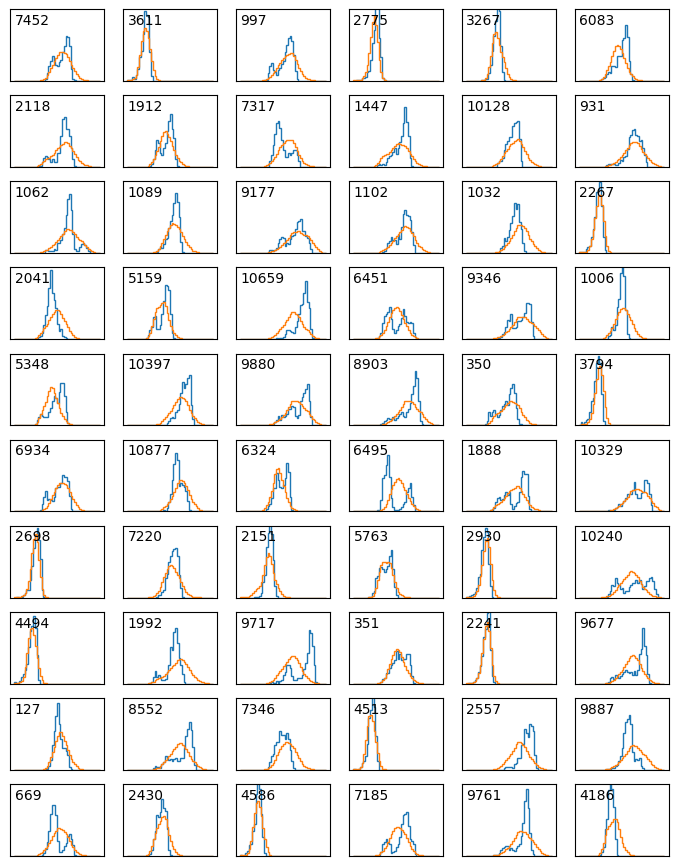

In [159]:
w = []
h = []

width_inch = 8.5
height_inch = 11
n_x = 6
n_y = 10
fig, axs = plt.subplots(n_y, n_x, figsize=(width_inch, height_inch))

offset = 0
for i in range(offset, len(data.train.row_keys)+offset):
    if i-offset == n_x*n_y:
        break

    i_x = (i-offset) % n_x
    i_y = int((i-offset)/n_x)

    ax = axs[i_y][i_x]
    ax.stairs(data.train.targets[i], data.bin_edges/np.log(10))

    logits = model.forward(torch.from_numpy(data.train.sequences[i]),
                           torch.from_numpy(data.train.structures[i]),
                           torch.from_numpy(data.train.static_features[i]),
                        embeddings=None)
    h.append(logits.detach().numpy())

    weights = torch.softmax(logits, dim=-1) # shape (batch_size, num_bins)
    w.append(weights.detach().numpy())

    xgrid = torch.outer(torch.ones(weights.shape[-1]), torch.arange(weights.shape[-1])) # shape (num_bins, num_bins)
    means = xgrid.T # shape (num_bins, num_bins)
    bandwidth = BANDWIDTH
    gaussians = 1/(math.sqrt(2*math.pi)*bandwidth)*torch.exp(-0.5*((xgrid - means)/bandwidth)**2) # shape (num_bins, num_bins)
    probs = weights @ gaussians # shape (batch_size, num_bins)
    normalizations = torch.ones(probs.shape[-1]) # shape (batch_size, num_bins)
    probs /= normalizations # shape (batch_size, num_bins)
    probs = probs.detach().numpy()
    ax.stairs(probs, data.bin_edges/np.log(10))

    ax.set_ylim(0,0.2)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.text(0.05, 0.95, str(data.train.row_keys[i]), transform=ax.transAxes, verticalalignment='top')

In [160]:
w = np.array(w)
np.std(w, axis=0)

array([7.29373824e-06, 5.21446811e-03, 5.46315368e-06, 5.01211525e-06,
       5.04803666e-06, 5.40363544e-06, 5.03806223e-06, 8.28669127e-03,
       6.55848726e-06, 1.57770172e-01, 1.18401789e-04, 1.60015152e-05,
       2.48976111e-01, 1.63138993e-05, 2.19278998e-04, 4.30494249e-02,
       2.43565496e-02, 9.00590196e-02, 1.74308401e-02, 1.14560705e-02,
       9.64455213e-03, 1.18746541e-01, 4.06788364e-02, 2.79184449e-02,
       2.47461367e-02, 2.86490340e-02, 5.39655164e-02, 4.70434725e-02,
       1.03333010e-03, 4.76092246e-04, 1.21860631e-01, 4.30012820e-04,
       5.14645246e-04, 2.75889542e-02, 7.97801763e-02, 8.68343189e-03,
       2.68100284e-05, 1.39136668e-04, 5.81774637e-02, 1.46695820e-05,
       1.65586098e-05, 2.66305283e-02, 8.15696058e-06, 8.04209594e-06,
       1.05912993e-02, 7.61822685e-06, 6.66600590e-06, 6.48387049e-06,
       7.36506217e-06, 8.63417245e-06], dtype=float32)

In [161]:
h = np.array(h)
np.std(h, axis=0)

array([ 0.88628316,  7.854696  ,  0.8784562 ,  0.9045201 ,  0.92168653,
        1.89531   ,  1.0027428 ,  7.877515  ,  1.9060203 , 10.78637   ,
        4.316409  ,  1.8186152 ,  9.94201   ,  1.0763149 ,  2.6213355 ,
        2.940424  ,  2.2716854 ,  2.7114315 ,  1.5134623 ,  0.7627403 ,
        0.61322886,  1.8789454 ,  2.16527   ,  0.9786581 ,  1.094834  ,
        1.5090365 ,  2.1951275 ,  2.8015685 ,  1.6798422 ,  1.6242942 ,
        4.0519934 ,  2.113462  ,  2.2811563 ,  4.7008524 ,  5.784795  ,
        4.6361876 ,  0.60163915,  2.1107714 ,  6.453423  ,  0.57744414,
        0.66879845,  6.2985845 ,  0.67571145,  0.6832703 ,  6.416828  ,
        0.66990983,  0.70911795,  0.78229475,  0.73195577,  0.698625  ],
      dtype=float32)

In [162]:
model.BATCHING

'padded'

In [75]:
embeddings_dict = torch.load(EMBEDDING_PATH)
train_loader = make_dataloader(data.train, batching=model.BATCHING, batch_size=32, shuffle=True, embedding_dict=embeddings_dict)

In [76]:
for sequences, structures, statics, targets, embeds, lengths in train_loader:
    #print(sequences.shape)
    print(sequences.std(dim=0).mean().item(),
          structures.std(dim=0).mean().item(),
          statics.std(dim=0).mean().item())

0.22837598621845245 0.24087674915790558 0.7731809020042419
0.2735397219657898 0.280783087015152 0.83114093542099
0.2885758876800537 0.29298922419548035 1.0368391275405884
0.25122255086898804 0.25660911202430725 1.4424376487731934
0.2521970570087433 0.2674678564071655 0.9223086833953857
0.25626417994499207 0.2689751982688904 0.8341054320335388
0.3069630265235901 0.31315699219703674 0.7511350512504578
0.22843334078788757 0.23695144057273865 0.7798891663551331
0.30188727378845215 0.3043622672557831 1.0920840501785278
0.2833115756511688 0.2956066131591797 0.7848604321479797
0.2614814341068268 0.2716248631477356 0.9279477596282959
0.3037749230861664 0.3138868808746338 0.8996109962463379
0.3219386339187622 0.3318806290626526 0.7975619435310364
0.27377578616142273 0.2843784987926483 1.041507363319397
0.25556835532188416 0.2661426067352295 0.8817042708396912
0.2411659210920334 0.2514646351337433 1.2718558311462402
0.30871066451072693 0.31067803502082825 0.946960985660553
0.24063456058502197 0.